# IAG Trading Algoritmico — Version Diaria con Posicion Fija
## Pipeline: EDA → Features → Triple-Barrier → Modelos → Backtest

### Por que IAG
1. Mayor volatilidad estructural (~35-45% anual) → barreras TB mas anchas, labels mas limpios
2. Ciclo post-COVID pronunciado → momentum mas claro (Moskowitz et al., 2012)
3. Sensibilidad a Brent (25-30% costes operativos) → features macro mas predictivas
4. Menos eficiente que BBVA → mas anomalias explotables por ML

### Sizing: posicion fija 30%
Con AUC ~0.51, Kelly fraccional da posiciones de <2% — insuficiente para cubrir costes.
Posicion fija del 30% garantiza participacion meaningful. (Thorp, 2006)

In [1]:
# CELDA 1: Imports y parametros globales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json
warnings.filterwarnings('ignore')

import yfinance as yf
from scipy import stats
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.ensemble      import RandomForestClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.inspection    import permutation_importance
from sklearn.metrics       import (roc_auc_score, f1_score, precision_score,
                                    recall_score, accuracy_score, roc_curve)
from xgboost import XGBClassifier

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})
PALETTE = ['#2563EB','#DC2626','#16A34A','#9333EA','#D97706']
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- PARAMETROS GLOBALES (pre-registrados) ---
ACTIVO       = 'IAG.MC'
ANNUALIZE    = 252
THETA        = 2.0   # TP: 2x vol diaria (mayor que BBVA por alta vol de IAG)
PHI          = 1.0   # SL: 1x vol diaria
H_DAYS       = 20    # horizonte 20 dias habiles (~4 semanas)
VOL_WINDOW   = 60    # ventana vol ex-ante (dias)
EMBARGO_DAYS = 20
CV_SPLITS    = 5
WF_WINDOW    = 756   # ventana walk-forward (~3 anos)
WF_RETRAIN   = 20    # re-entrenar cada 20 dias
THRESHOLD    = 0.50  # umbral señal LONG
FIXED_POS    = 0.30  # posicion fija 30%
COST_BPS     = 0.0020
CUTOFF_TEST  = pd.Timestamp('2023-01-01')
START, END   = '2015-01-01', '2025-12-31'

print(f'Activo: {ACTIVO} | THETA={THETA} | H={H_DAYS}d | WF={WF_WINDOW}d | Pos={FIXED_POS*100:.0f}%')

Activo: IAG.MC | THETA=2.0 | H=20d | WF=756d | Pos=30%


---
# BLOQUE 1: Carga de Datos y EDA

In [2]:
# CELDA 2: Descarga de datos
TICKERS = {
    'IAG.MC':   'IAG',
    '^IBEX':    'IBEX',
    '^TNX':     'TNX',
    '^VIX':     'VIX',
    'EURUSD=X': 'EURUSD',
    'BZ=F':     'BRENT',
    'EXV1.DE':  'BANKS_EU',
}

print('Descargando datos diarios...')
raw = yf.download(list(TICKERS.keys()), start=START, end=END,
                  auto_adjust=True, progress=False)

# --- Fix robusto para MultiIndex de yfinance ---
if isinstance(raw.columns, pd.MultiIndex):
    # Nuevo yfinance: columnas son (Price, Ticker)
    # Intentar 'Close' primero, luego 'Adj Close'
    if 'Close' in raw.columns.get_level_values(0):
        close = raw['Close'].copy()
    else:
        close = raw['Adj Close'].copy()
    # Renombrar columnas con nombres cortos
    ticker_to_name = {k: v for k, v in TICKERS.items()}
    close.columns = [ticker_to_name.get(c, c) for c in close.columns]
else:
    close = raw[['Close']].rename(columns={'Close': 'IAG'})

close.index = pd.to_datetime(close.index)
if close.index.tz is not None:
    close.index = close.index.tz_localize(None)

# Verificar columnas esperadas
expected = list(TICKERS.values())
missing  = [c for c in expected if c not in close.columns]
if missing:
    print(f'AVISO: columnas no encontradas: {missing}')
    print(f'Columnas disponibles: {list(close.columns)}')

# Forward-fill hasta 3 dias (festivos)
df_daily = close.ffill(limit=3)

# Eliminar filas donde IAG tenga NaN
df_daily = df_daily[df_daily['IAG'].notna()].copy()

# --- High/Low de IAG para Triple-Barrier ---
print('Descargando High/Low IAG...')
iag_raw = yf.download(ACTIVO, start=START, end=END,
                      auto_adjust=True, progress=False)
# Fix columnas
if isinstance(iag_raw.columns, pd.MultiIndex):
    iag_raw.columns = iag_raw.columns.get_level_values(0)
iag_raw.index = pd.to_datetime(iag_raw.index)
if iag_raw.index.tz is not None:
    iag_raw.index = iag_raw.index.tz_localize(None)

# Detectar nombre correcto de columnas High/Low
high_col = 'High' if 'High' in iag_raw.columns else iag_raw.columns[iag_raw.columns.str.lower()=='high'][0]
low_col  = 'Low'  if 'Low'  in iag_raw.columns else iag_raw.columns[iag_raw.columns.str.lower()=='low'][0]
iag_high = iag_raw[high_col].ffill()
iag_low  = iag_raw[low_col].ffill()

# Retornos logaritmicos
df_rets = np.log(df_daily / df_daily.shift(1)).dropna()

print(f'Datos diarios: {len(df_daily)} dias')
print(f'Periodo: {df_daily.index[0].date()} - {df_daily.index[-1].date()}')
print(f'Columnas: {list(df_daily.columns)}')
print(f'IAG NaN: {df_daily["IAG"].isna().sum()}')

Descargando datos diarios...
Descargando High/Low IAG...
Datos diarios: 2865 dias
Periodo: 2015-01-02 - 2025-12-30
Columnas: ['BRENT', 'EURUSD', 'BANKS_EU', 'IAG', 'IBEX', 'TNX', 'VIX']
IAG NaN: 0


In [3]:
# CELDA 3: EDA estadisticos
r = df_rets['IAG'].dropna()

media_anual = r.mean() * ANNUALIZE
vol_anual   = r.std()  * np.sqrt(ANNUALIZE)
sharpe_bh   = media_anual / vol_anual
jb_stat, jb_pval = stats.jarque_bera(r)

print('===================================================')
print('ESTADISTICOS RETORNOS DIARIOS — IAG')
print('===================================================')
print(f'Observaciones:       {len(r)}')
print(f'Media anualizada:    {media_anual*100:.2f}%')
print(f'Volatilidad anual:   {vol_anual*100:.2f}%')
print(f'Sharpe Buy&Hold:     {sharpe_bh:.3f}')
print(f'Skewness:            {r.skew():.4f}')
print(f'Curtosis:            {r.kurtosis():.4f}')
print(f'Min diario:          {r.min()*100:.2f}%')
print(f'Max diario:          {r.max()*100:.2f}%')
print(f'Jarque-Bera p-valor: {jb_pval:.2e}')

adf_p = adfuller(r, autolag='AIC')[1]
print(f'ADF retorno IAG:     p={adf_p:.4f} - {"Estacionario" if adf_p<0.05 else "NO estacionario"}')

lb = acorr_ljungbox(r**2, lags=[5,10,20], return_df=True)
print('\nLjung-Box retornos^2 (clustering vol):')
for lag, row_lb in lb.iterrows():
    sig = 'SIG' if row_lb['lb_pvalue'] < 0.05 else '---'
    print(f'  lag {lag:2d}: p={row_lb["lb_pvalue"]:.4f} {sig}')

ESTADISTICOS RETORNOS DIARIOS — IAG
Observaciones:       2864
Media anualizada:    3.86%
Volatilidad anual:   44.30%
Sharpe Buy&Hold:     0.087
Skewness:            -1.1408
Curtosis:            17.4473
Min diario:          -32.71%
Max diario:          23.17%
Jarque-Bera p-valor: 0.00e+00
ADF retorno IAG:     p=0.0000 - Estacionario

Ljung-Box retornos^2 (clustering vol):
  lag  5: p=0.0000 SIG
  lag 10: p=0.0000 SIG
  lag 20: p=0.0000 SIG


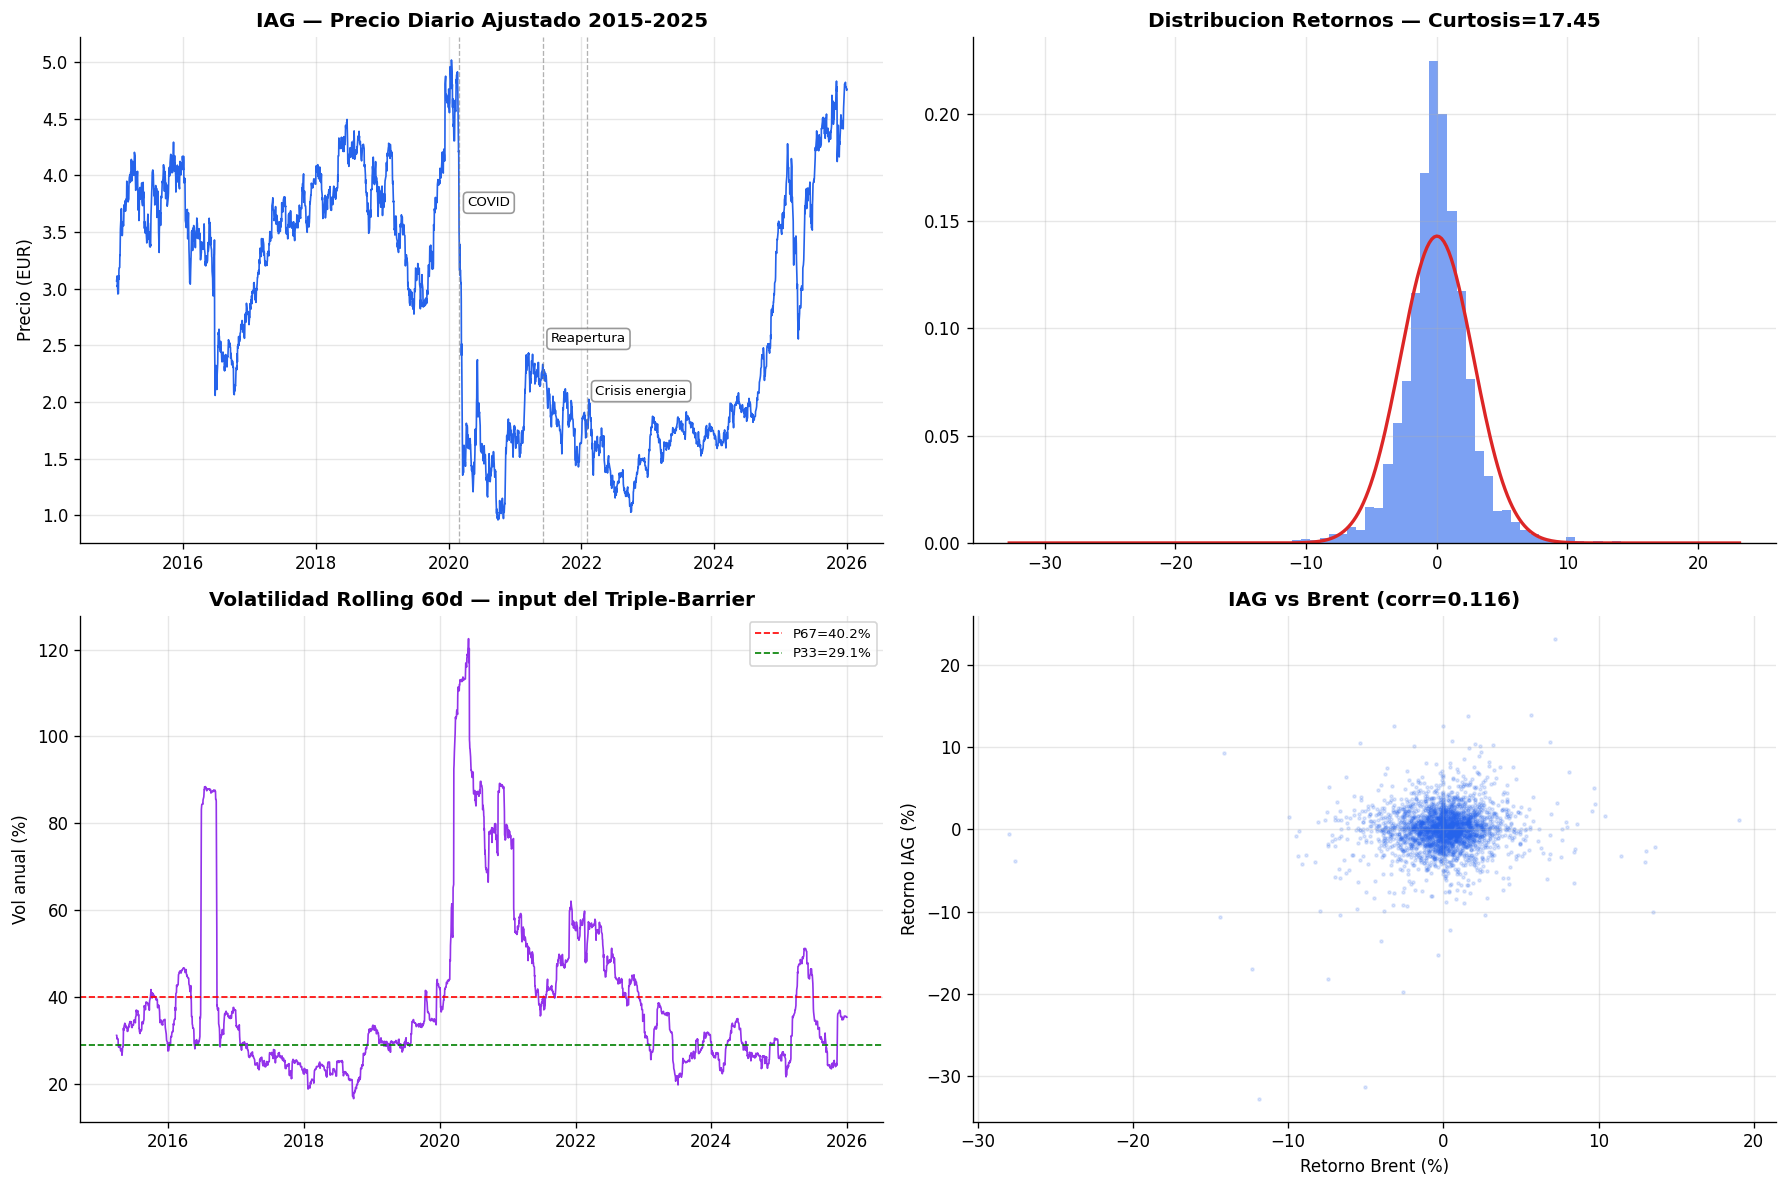

In [4]:
# CELDA 4: Visualizacion EDA
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0,0]
ax.plot(df_daily.index, df_daily['IAG'], color=PALETTE[0], lw=1)

# Se ha eliminado ('2023-06','Record viajeros') de la lista
for fd, txt in [('2020-03','COVID'), ('2021-06','Reapertura'),
                ('2022-02','Crisis energia')]:
    idx = df_daily.index.asof(pd.Timestamp(fd))
    ax.axvline(idx, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax.annotate(txt, xy=(idx, df_daily.loc[idx,'IAG']),
                xytext=(5, 15), textcoords='offset points', 
                fontsize=8, color='black',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

ax.set_title('IAG — Precio Diario Ajustado 2015-2025', fontweight='bold')
ax.set_ylabel('Precio (EUR)')

ax = axes[0,1]
r_pct = r * 100
ax.hist(r_pct, bins=80, density=True, alpha=0.6, color=PALETTE[0])
xv = np.linspace(r_pct.min(), r_pct.max(), 300)
ax.plot(xv, stats.norm.pdf(xv, r_pct.mean(), r_pct.std()), color=PALETTE[1], lw=2)
ax.set_title(f'Distribucion Retornos — Curtosis={r.kurtosis():.2f}', fontweight='bold')

ax = axes[1,0]
vol_60 = r.shift(1).rolling(60).std() * np.sqrt(ANNUALIZE) * 100
ax.plot(vol_60.index, vol_60, color=PALETTE[3], lw=1)
ax.axhline(vol_60.quantile(0.67), color='red',   ls='--', lw=1, label=f'P67={vol_60.quantile(0.67):.1f}%')
ax.axhline(vol_60.quantile(0.33), color='green', ls='--', lw=1, label=f'P33={vol_60.quantile(0.33):.1f}%')
ax.set_title('Volatilidad Rolling 60d — input del Triple-Barrier', fontweight='bold')
ax.set_ylabel('Vol anual (%)')
ax.legend(fontsize=8)

ax = axes[1,1]
if 'BRENT' in df_rets.columns:
    rb = df_rets['BRENT'].dropna()
    common = r.index.intersection(rb.index)
    ax.scatter(rb.loc[common]*100, r.loc[common]*100, alpha=0.15, s=3, color=PALETTE[0])
    ax.set_xlabel('Retorno Brent (%)')
    ax.set_ylabel('Retorno IAG (%)')
    ax.set_title(f'IAG vs Brent (corr={r.loc[common].corr(rb.loc[common]):.3f})', fontweight='bold')
else:
    ax.text(0.5,0.5,'Brent no disponible', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('iag_fig1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

---
# BLOQUE 2: Feature Engineering

In [5]:
# CELDA 5: Fractional Differentiation
def get_weights(d, threshold=1e-4):
    w = [1.0]; k = 1
    while True:
        wk = -w[-1]*(d-k+1)/k
        if abs(wk) < threshold: break
        w.append(wk); k += 1
    return np.array(w)

def frac_diff(series, d, threshold=1e-4):
    w = get_weights(d, threshold); K = len(w)
    result = pd.Series(index=series.index, dtype=float)
    for t in range(K-1, len(series)):
        result.iloc[t] = np.dot(w, series.iloc[t-K+1:t+1].values[::-1])
    return result

def find_min_d(series, step=0.05):
    for d in np.arange(step, 1.0+step, step):
        fd = frac_diff(series, round(d,2))
        fc = fd.dropna()
        if len(fc) >= 30 and adfuller(fc, autolag='AIC')[1] < 0.05:
            return round(d, 2)
    return 1.0

print('Calculando d optimo IAG (puede tardar ~60s)...')
price_log = np.log(df_daily['IAG'])
D_OPT = find_min_d(price_log)
fd_price = frac_diff(price_log, D_OPT)
print(f'd optimo: {D_OPT}')
adf_fd = adfuller(fd_price.dropna(), autolag='AIC')[1]
print(f'ADF fd_price: p={adf_fd:.4f} - Estacionario: {adf_fd < 0.05}')

Calculando d optimo IAG (puede tardar ~60s)...
d optimo: 0.2
ADF fd_price: p=0.0136 - Estacionario: True


In [6]:
# CELDA 6: Features diarias
df_feat = pd.DataFrame(index=df_daily.index)
r_iag   = np.log(df_daily['IAG'] / df_daily['IAG'].shift(1))

# A: Momentum
for k, name in [(1,'ret_1d'),(5,'ret_5d'),(20,'ret_20d'),
                (60,'ret_60d'),(120,'ret_120d'),(252,'ret_252d')]:
    df_feat[name] = np.log(df_daily['IAG'] / df_daily['IAG'].shift(k))
df_feat['ret_1d_lag1'] = df_feat['ret_1d'].shift(1)

# B: Mean Reversion
ps = df_daily['IAG'].shift(1)
df_feat['zscore_20d']  = (df_daily['IAG'] - ps.rolling(20).mean())  / ps.rolling(20).std()
df_feat['zscore_252d'] = (df_daily['IAG'] - ps.rolling(252).mean()) / ps.rolling(252).std()
delta_p = df_daily['IAG'].diff()
rs = delta_p.clip(lower=0).ewm(com=13,adjust=False).mean() / \
     (-delta_p).clip(lower=0).ewm(com=13,adjust=False).mean().replace(0, np.nan)
df_feat['rsi_14'] = 100 - (100 / (1 + rs))

# C: Volatilidad
rs_shifted = r_iag.shift(1)
df_feat['vol_20d']   = rs_shifted.rolling(20).std()  * np.sqrt(ANNUALIZE)
df_feat['vol_60d']   = rs_shifted.rolling(60).std()  * np.sqrt(ANNUALIZE)
df_feat['vol_ratio'] = df_feat['vol_20d'] / df_feat['vol_60d'].replace(0, np.nan)

# D: Macro
df_feat['delta_tnx']  = df_daily['TNX'].diff()  if 'TNX' in df_daily.columns else np.nan
df_feat['vix_level']  = df_daily['VIX']          if 'VIX' in df_daily.columns else np.nan
df_feat['delta_vix']  = df_daily['VIX'].diff()   if 'VIX' in df_daily.columns else np.nan
df_feat['ret_eurusd'] = np.log(df_daily['EURUSD'] / df_daily['EURUSD'].shift(1)) if 'EURUSD' in df_daily.columns else np.nan
df_feat['ret_brent']  = np.log(df_daily['BRENT']  / df_daily['BRENT'].shift(1))  if 'BRENT'  in df_daily.columns else np.nan

# E: Relativo
if 'IBEX' in df_daily.columns:
    df_feat['alpha_ibex'] = df_feat['ret_1d'] - np.log(df_daily['IBEX']/df_daily['IBEX'].shift(1))
if 'BANKS_EU' in df_daily.columns:
    df_feat['ret_banks_eu'] = np.log(df_daily['BANKS_EU']/df_daily['BANKS_EU'].shift(1))

# F: Fractional differentiation
df_feat['fd_price'] = fd_price

# Limpiar columnas con todo NaN (activos no descargados)
df_feat = df_feat.dropna(axis=1, how='all')
ALL_FEATURES = list(df_feat.columns)
df_feat = df_feat.dropna()

print(f'Features: {len(ALL_FEATURES)}')
print(f'Obs validas: {len(df_feat)}')
print(f'Periodo: {df_feat.index[0].date()} - {df_feat.index[-1].date()}')

Features: 21
Obs validas: 2369
Periodo: 2016-11-28 - 2025-12-30


In [7]:
# CELDA 7: Feature selection por correlacion con target
ret_futuro = r_iag.shift(-1).reindex(df_feat.index)
corrs = {f: df_feat[f].corr(ret_futuro) for f in ALL_FEATURES}
corr_s = pd.Series(corrs).sort_values(key=abs, ascending=False)

print('Correlacion features con retorno IAG siguiente dia:')
print(corr_s.round(4).to_string())

# Top 12 features
TOP_FEATURES = list(corr_s.head(12).index)
print(f'\nTop-12 seleccionadas:')
for i, f in enumerate(TOP_FEATURES):
    print(f'  {i+1:2d}. {f:20s} corr={corrs[f]:+.4f}')

Correlacion features con retorno IAG siguiente dia:
ret_1d_lag1     0.0966
ret_5d          0.0935
vix_level      -0.0747
delta_vix      -0.0629
ret_1d          0.0407
zscore_20d      0.0399
rsi_14          0.0383
alpha_ibex      0.0381
ret_20d         0.0367
ret_banks_eu    0.0283
ret_brent       0.0276
delta_tnx      -0.0211
vol_ratio      -0.0185
vol_20d        -0.0169
ret_252d       -0.0160
zscore_252d     0.0083
vol_60d        -0.0079
ret_120d       -0.0065
fd_price       -0.0038
ret_60d         0.0015
ret_eurusd     -0.0001

Top-12 seleccionadas:
   1. ret_1d_lag1          corr=+0.0966
   2. ret_5d               corr=+0.0935
   3. vix_level            corr=-0.0747
   4. delta_vix            corr=-0.0629
   5. ret_1d               corr=+0.0407
   6. zscore_20d           corr=+0.0399
   7. rsi_14               corr=+0.0383
   8. alpha_ibex           corr=+0.0381
   9. ret_20d              corr=+0.0367
  10. ret_banks_eu         corr=+0.0283
  11. ret_brent            corr=+0.0276
  

---
# BLOQUE 3: Triple-Barrier Labeling

In [8]:
# CELDA 8: Triple-Barrier Labeling Diario
# THETA=2.0 para IAG (mayor vol → barreras mas anchas → mas label=1)
def triple_barrier_daily(close, high, low, vol_60d,
                         theta=2.0, phi=1.0, h=20, annualize=252):
    """
    Triple-Barrier Method en frecuencia diaria.
    Lopez de Prado (2018), AFML cap. 3
    Anti look-ahead: vol_60d calculada con shift(1) en Bloque 2
    """
    results = []
    close_arr = close.values
    high_arr  = high.reindex(close.index).ffill().values
    low_arr   = low.reindex(close.index).ffill().values
    # vol diaria = vol anualizada / sqrt(252)
    vol_arr   = (vol_60d.reindex(close.index).ffill() / np.sqrt(annualize)).values
    dates     = close.index
    n         = len(close)

    for t in range(n - h - 1):
        p0    = close_arr[t]
        vol_t = vol_arr[t]

        if np.isnan(p0) or np.isnan(vol_t) or vol_t <= 0:
            results.append({'date': dates[t], 'label': np.nan,
                            'barrier_hit': 'nan', 'vol_daily': np.nan})
            continue

        tp = p0 * (1 + theta * vol_t)
        sl = p0 * (1 - phi   * vol_t)
        label = 0; barrier_hit = 'timeout'

        for i in range(1, h + 1):
            if t + i >= n: break
            hi = high_arr[t + i]
            lo = low_arr[t + i]
            if np.isnan(hi) or np.isnan(lo): continue
            if hi >= tp and lo <= sl:
                label = 0; barrier_hit = 'both'; break
            elif hi >= tp:
                label = 1; barrier_hit = 'tp';   break
            elif lo <= sl:
                label = 0; barrier_hit = 'sl';   break

        results.append({
            'date':        dates[t],
            'label':       int(label),
            'barrier_hit': barrier_hit,
            'entry_price': float(p0),
            'tp':          float(tp),
            'sl':          float(sl),
            'vol_daily':   float(vol_t),
        })

    df_out = pd.DataFrame(results)
    df_out['date'] = pd.to_datetime(df_out['date'])
    return df_out.set_index('date')


print(f'Calculando Triple-Barrier labels (theta={THETA}, phi={PHI}, h={H_DAYS}d)...')
print('(2-3 minutos)')

vol_60d_aligned = df_feat['vol_60d'].reindex(df_daily.index)

df_labels = triple_barrier_daily(
    close   = df_daily['IAG'],
    high    = iag_high,
    low     = iag_low,
    vol_60d = vol_60d_aligned,
    theta=THETA, phi=PHI, h=H_DAYS,
)

# Eliminar NaN
df_labels = df_labels[df_labels['label'].notna()].copy()
df_labels['label'] = df_labels['label'].astype(int)

# Naive label
ret_fwd = np.log(df_daily['IAG'].shift(-H_DAYS) / df_daily['IAG'])
y_naive = (ret_fwd > 0).astype(float).reindex(df_labels.index)

print(f'\nTotal labels: {len(df_labels)}')
dist = df_labels['label'].value_counts().sort_index()
n0 = dist.get(0, 0); n1 = dist.get(1, 0)
print(f'Label 0 (SL/timeout): {n0} ({n0/len(df_labels)*100:.1f}%)')
print(f'Label 1 (TP):         {n1} ({n1/len(df_labels)*100:.1f}%)')

print('\nPor barrera tocada:')
for hit, cnt in df_labels['barrier_hit'].value_counts().items():
    print(f'  {hit}: {cnt} ({cnt/len(df_labels)*100:.1f}%)')

if n1 == 0:
    print('\nADVERTENCIA: ningun label=1. Subir THETA a 2.5 o H_DAYS a 30.')
elif n1/len(df_labels) < 0.10:
    print(f'\nAVISO: solo {n1/len(df_labels)*100:.1f}% positivos. Puede ser suficiente.')
else:
    print('\nBalance aceptable para modelado.')

common = df_labels.index.intersection(y_naive.dropna().index)
disc   = (df_labels.loc[common,'label'].astype(int) != y_naive.loc[common].astype(int)).sum()
print(f'Discrepancias naive vs TB: {disc} ({disc/len(common)*100:.1f}%)')

Calculando Triple-Barrier labels (theta=2.0, phi=1.0, h=20d)...
(2-3 minutos)

Total labels: 2348
Label 0 (SL/timeout): 1523 (64.9%)
Label 1 (TP):         825 (35.1%)

Por barrera tocada:
  sl: 1510 (64.3%)
  tp: 825 (35.1%)
  both: 10 (0.4%)
  timeout: 3 (0.1%)

Balance aceptable para modelado.
Discrepancias naive vs TB: 873 (37.2%)


In [9]:
# CELDA 9: Dataset final X, y
common_idx = df_feat.index.intersection(df_labels.index)
X_all      = df_feat.loc[common_idx, TOP_FEATURES].copy()
y_all      = df_labels.loc[common_idx, 'label'].astype(int)
ret_daily  = r_iag.shift(-1).reindex(common_idx)

# Eliminar NaN residuales
valid  = X_all.notna().all(axis=1) & y_all.notna() & ret_daily.notna()
X_all  = X_all[valid]
y_all  = y_all[valid]
ret_daily = ret_daily[valid]

# Split temporal
train_mask = X_all.index < CUTOFF_TEST
test_mask  = X_all.index >= CUTOFF_TEST
X_train = X_all[train_mask]; y_train = y_all[train_mask]
X_test  = X_all[test_mask];  y_test  = y_all[test_mask]

print(f'Dataset final IAG:')
print(f'  Total:    {len(X_all)} obs | {X_all.shape[1]} features')
print(f'  Train:    {len(X_train)} obs ({X_train.index[0].date()} - {X_train.index[-1].date()})')
print(f'  Test OOS: {len(X_test)} obs')
print(f'  Balance:  {y_train.mean()*100:.1f}% label=1 en train')

# Verificar que hay las dos clases en train
if y_train.nunique() < 2:
    print('ERROR: solo una clase en train. Subir THETA.')
else:
    print('OK: dos clases presentes en train.')

Dataset final IAG:
  Total:    2348 obs | 12 features
  Train:    1590 obs (2016-11-28 - 2022-12-30)
  Test OOS: 758 obs
  Balance:  33.6% label=1 en train
OK: dos clases presentes en train.


---
# BLOQUE 4: Modelos con Purged K-Fold CV

In [10]:
# CELDA 10: Purged K-Fold + definicion de modelos
def purged_kfold_splits(index, n_splits=5, embargo_days=20, horizon_days=20):
    """Lopez de Prado (2018), AFML cap. 7"""
    n = len(index)
    fold_size = n // n_splits
    for k in range(n_splits):
        ts_i = k * fold_size
        te_i = ts_i + fold_size if k < n_splits - 1 else n
        ts = index[ts_i]; te = index[te_i - 1]
        purge_cut  = ts - pd.Timedelta(days=int(horizon_days * 1.5))
        embargo_end = te + pd.Timedelta(days=int(embargo_days * 1.5))
        test_m    = (index >= ts) & (index <= te)
        purge_m   = (index >  purge_cut)  & (index < ts)
        embargo_m = (index >  te)         & (index <= embargo_end)
        train_m   = ~(test_m | purge_m | embargo_m)
        yield np.where(train_m)[0], np.where(test_m)[0]

neg_c = (y_train == 0).sum()
pos_c = (y_train == 1).sum()
scale_pos = neg_c / pos_c if pos_c > 0 else 1.0

MODELS = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=5, min_samples_leaf=20,
        max_features='sqrt', class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=20,
        scale_pos_weight=scale_pos, eval_metric='auc',
        random_state=RANDOM_STATE, verbosity=0,
    ),
}

print(f'Modelos: {list(MODELS.keys())}')
print(f'scale_pos_weight XGB: {scale_pos:.3f}')
print(f'Balance train: {y_train.mean()*100:.1f}% positivos')
print('\nVerificacion splits:')
for k, (tr, te) in enumerate(purged_kfold_splits(X_train.index)):
    print(f'  Fold {k+1}: train={len(tr)} | test={len(te)} | eliminadas={len(X_train)-len(tr)-len(te)}')


Modelos: ['Random Forest', 'XGBoost']
scale_pos_weight XGB: 1.978
Balance train: 33.6% positivos

Verificacion splits:
  Fold 1: train=1250 | test=318 | eliminadas=22
  Fold 2: train=1229 | test=318 | eliminadas=43
  Fold 3: train=1230 | test=318 | eliminadas=42
  Fold 4: train=1229 | test=318 | eliminadas=43
  Fold 5: train=1251 | test=318 | eliminadas=21


In [11]:
# CELDA 11: Entrenamiento Purged K-Fold CV
print('Ejecutando Purged K-Fold CV IAG...')
print('(5-8 minutos)\n')

cv_res = {name: {'y_true':[], 'y_prob':[], 'y_pred':[], 'fold_auc':[]}
          for name in MODELS}

X_tr_arr = X_train.values
y_tr_arr = y_train.values.astype(int)

for k, (tr_idx, val_idx) in enumerate(purged_kfold_splits(
        X_train.index, n_splits=5, embargo_days=EMBARGO_DAYS, horizon_days=H_DAYS)):

    X_tr, X_val = X_tr_arr[tr_idx], X_tr_arr[val_idx]
    y_tr, y_val = y_tr_arr[tr_idx], y_tr_arr[val_idx]

    # Saltar fold si solo hay una clase en train o val
    if len(np.unique(y_tr)) < 2 or len(np.unique(y_val)) < 2:
        print(f'Fold {k+1}: saltado (una sola clase)')
        for name in MODELS:
            cv_res[name]['fold_auc'].append(np.nan)
        continue

    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)

    for name, model in MODELS.items():
        model.fit(X_tr_sc, y_tr)

        # Fix robusto: predict_proba puede devolver 1 columna si solo hay 1 clase
        proba = model.predict_proba(X_val_sc)
        if proba.shape[1] == 2:
            probs = proba[:, 1]
        else:
            # Una sola clase predicha — sin informacion
            probs = np.full(len(X_val), 0.5)

        preds = (probs >= THRESHOLD).astype(int)
        fauc  = roc_auc_score(y_val, probs)

        cv_res[name]['y_true'].extend(y_val.tolist())
        cv_res[name]['y_prob'].extend(probs.tolist())
        cv_res[name]['y_pred'].extend(preds.tolist())
        cv_res[name]['fold_auc'].append(fauc)

    rf_auc  = cv_res['Random Forest']['fold_auc'][-1]
    xgb_auc = cv_res['XGBoost']['fold_auc'][-1]
    print(f'Fold {k+1}/5 | RF={rf_auc:.4f} | XGB={xgb_auc:.4f}')

print('\nCV completado.')

Ejecutando Purged K-Fold CV IAG...
(5-8 minutos)

Fold 1/5 | RF=0.5860 | XGB=0.5914
Fold 2/5 | RF=0.5532 | XGB=0.5548
Fold 3/5 | RF=0.5361 | XGB=0.5531
Fold 4/5 | RF=0.4943 | XGB=0.5253
Fold 5/5 | RF=0.5554 | XGB=0.5295

CV completado.


METRICAS ML — PURGED K-FOLD CV IAG
                  AUC  AUC std  AUC min  AUC max  Precision(1)  Recall(1)   F1(1)
Modelo                                                                           
Random Forest  0.5335   0.0300   0.4943   0.5860        0.3431     0.3933  0.3665
XGBoost        0.5448   0.0235   0.5253   0.5914        0.3619     0.4513  0.4017

Modelo primario: XGBoost (AUC=0.5448)

Calculando feature importance...


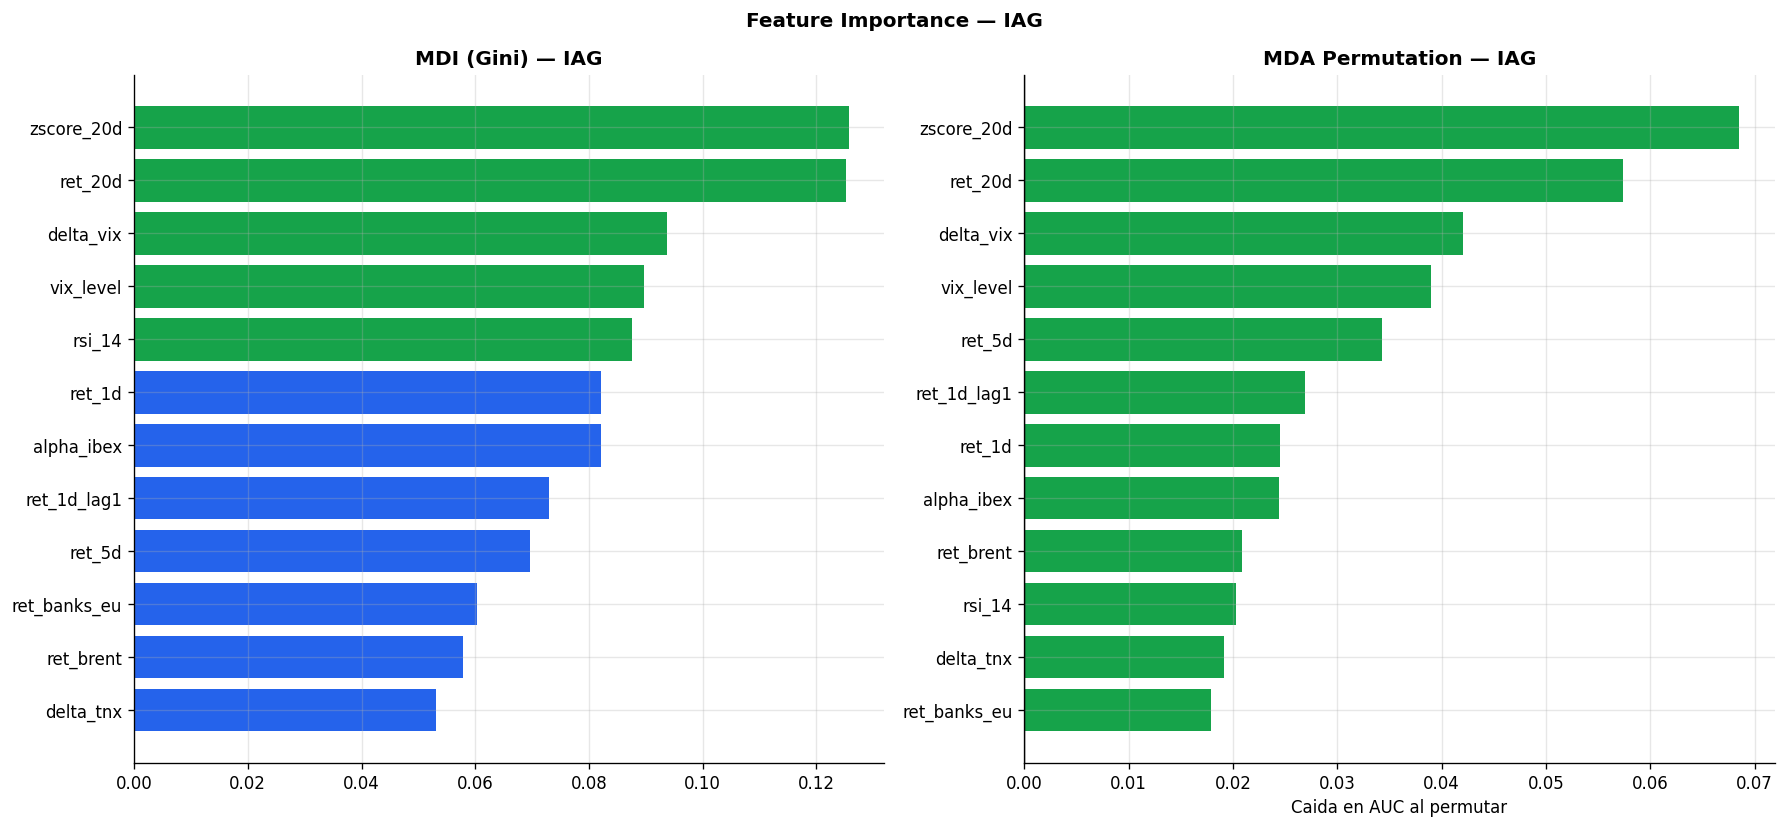


Top-5 MDA:
  zscore_20d          : +0.06850
  ret_20d             : +0.05736
  delta_vix           : +0.04209
  vix_level           : +0.03899
  ret_5d              : +0.03426


In [12]:
# CELDA 12: Metricas ML + Feature Importance
print('=' * 60)
print('METRICAS ML — PURGED K-FOLD CV IAG')
print('=' * 60)

metrics_rows = []
for name in MODELS:
    yt = np.array(cv_res[name]['y_true'])
    yp = np.array(cv_res[name]['y_pred'])
    yb = np.array(cv_res[name]['y_prob'])
    fa = [x for x in cv_res[name]['fold_auc'] if not np.isnan(x)]

    if len(yt) == 0 or len(np.unique(yt)) < 2:
        print(f'{name}: datos insuficientes para metricas')
        continue

    row = {
        'Modelo':       name,
        'AUC':          round(roc_auc_score(yt, yb), 4),
        'AUC std':      round(float(np.std(fa)) if fa else np.nan, 4),
        'AUC min':      round(float(np.min(fa)) if fa else np.nan, 4),
        'AUC max':      round(float(np.max(fa)) if fa else np.nan, 4),
        'Precision(1)': round(precision_score(yt, yp, zero_division=0), 4),
        'Recall(1)':    round(recall_score(yt, yp, zero_division=0), 4),
        'F1(1)':        round(f1_score(yt, yp, zero_division=0), 4),
    }
    metrics_rows.append(row)

df_metrics = pd.DataFrame(metrics_rows).set_index('Modelo')
print(df_metrics.to_string())
best_model_name = df_metrics['AUC'].idxmax()
print(f'\nModelo primario: {best_model_name} (AUC={df_metrics.loc[best_model_name,"AUC"]:.4f})')

# Feature Importance
print('\nCalculando feature importance...')
sc_full    = StandardScaler()
Xtr_sc     = sc_full.fit_transform(X_train.values)
ytr_int    = y_train.values.astype(int)

rf_fi = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=20,
    max_features='sqrt', class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
).fit(Xtr_sc, ytr_int)

mdi = pd.Series(rf_fi.feature_importances_, index=TOP_FEATURES)
mda_raw = permutation_importance(rf_fi, Xtr_sc, ytr_int, n_repeats=20,
                                  scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)
mda = pd.Series(mda_raw.importances_mean, index=TOP_FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
s = mdi.sort_values(ascending=True)
axes[0].barh(s.index, s.values, color=[PALETTE[2] if v>mdi.mean() else PALETTE[0] for v in s.values])
axes[0].set_title('MDI (Gini) — IAG', fontweight='bold')

s = mda.sort_values(ascending=True)
axes[1].barh(s.index, s.values, color=[PALETTE[2] if v>0 else PALETTE[1] for v in s.values])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('MDA Permutation — IAG', fontweight='bold')
axes[1].set_xlabel('Caida en AUC al permutar')

plt.suptitle('Feature Importance — IAG', fontweight='bold')
plt.tight_layout()
plt.savefig('iag_fig2_fi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop-5 MDA:')
for f, v in mda.sort_values(ascending=False).head(5).items():
    print(f'  {f:20s}: {v:+.5f}')

---
# BLOQUE 5+6: Walk-Forward Backtest con Posicion Fija 30%

In [13]:
# CELDA 13: Metricas financieras
def compute_metrics(returns, rf_daily=0.04/252):
    r = returns.dropna()
    if len(r) < 20: return {}
    n_years    = len(r) / ANNUALIZE
    total_ret  = (1 + r).prod() - 1
    ann_return = (1 + total_ret)**(1/n_years) - 1 if n_years > 0 else 0
    ann_vol    = r.std() * np.sqrt(ANNUALIZE)
    sharpe     = (r.mean() - rf_daily) / r.std() * np.sqrt(ANNUALIZE) if r.std() > 0 else 0
    r_neg      = r[r < 0]
    sortino    = (r.mean() - rf_daily) / r_neg.std() * np.sqrt(ANNUALIZE) if len(r_neg) > 1 else 0
    equity     = (1 + r).cumprod()
    mdd        = ((equity - equity.cummax()) / equity.cummax()).min()
    calmar     = ann_return / abs(mdd) if mdd != 0 else 0
    gains      = r[r > 0].sum()
    losses     = abs(r[r < 0].sum())
    return {
        'ROI anualizado (%)':    round(ann_return*100, 2),
        'Volatilidad anual (%)': round(ann_vol*100, 2),
        'Sharpe':                round(sharpe, 3),
        'Sortino':               round(sortino, 3),
        'Max Drawdown (%)':      round(mdd*100, 2),
        'Calmar':                round(calmar, 3),
        'Hit Ratio (%)':         round((r>0).mean()*100, 2),
        'Profit Factor':         round(gains/losses if losses>0 else np.inf, 3),
        'N dias':                len(r),
    }

print('Funciones financieras OK')

Funciones financieras OK


In [14]:
# CELDA 14: Walk-Forward Backtest
print(f'Walk-Forward IAG | Ventana={WF_WINDOW}d | Retrain={WF_RETRAIN}d | Pos={FIXED_POS*100:.0f}% fija')
print('(10-15 minutos)\n')

model_names = ['Random Forest', 'XGBoost']
wf_res = {n: {'dates':[],'probs':[],'positions':[],'ret_strat':[],'ret_bh':[],'costs':[]}
          for n in model_names}

X_arr   = X_all.values
y_arr   = y_all.values.astype(int)
ret_arr = ret_daily.values
dates   = X_all.index
n_total = len(X_arr)

last_models = {n: None for n in model_names}
last_scaler  = None
last_pos     = {n: 0.0 for n in model_names}

for t in range(WF_WINDOW, n_total - 1):
    if (t - WF_WINDOW) % WF_RETRAIN == 0 or last_models['Random Forest'] is None:
        X_tr = X_arr[t - WF_WINDOW : t]
        y_tr = y_arr[t - WF_WINDOW : t]

        # Saltar si solo hay una clase
        if len(np.unique(y_tr)) < 2:
            continue

        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(X_tr)
        last_scaler = sc

        neg_c = (y_tr == 0).sum(); pos_c = (y_tr == 1).sum()
        spw   = neg_c / pos_c if pos_c > 0 else 1.0

        last_models['Random Forest'] = RandomForestClassifier(
            n_estimators=300, max_depth=5, min_samples_leaf=20,
            max_features='sqrt', class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ).fit(X_tr_sc, y_tr)

        last_models['XGBoost'] = XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=20,
            scale_pos_weight=spw, eval_metric='auc',
            random_state=RANDOM_STATE, verbosity=0
        ).fit(X_tr_sc, y_tr)

        last_models['Naive Bayes'] = GaussianNB().fit(X_tr_sc, y_tr)

    if last_scaler is None:
        continue

    X_t_sc = last_scaler.transform(X_arr[t].reshape(1, -1))

    for name in model_names:
        if last_models[name] is None:
            continue

        # Fix predict_proba robusto
        proba = last_models[name].predict_proba(X_t_sc)
        prob  = proba[0, 1] if proba.shape[1] == 2 else 0.5

        signal   = 1 if prob >= THRESHOLD else 0
        position = FIXED_POS if signal == 1 else 0.0

        cost      = abs(position - last_pos[name]) * COST_BPS
        ret_next  = float(ret_arr[t+1]) if not np.isnan(ret_arr[t+1]) else 0.0
        ret_strat = position * ret_next - cost

        wf_res[name]['dates'].append(dates[t+1])
        wf_res[name]['probs'].append(prob)
        wf_res[name]['positions'].append(position)
        wf_res[name]['ret_strat'].append(ret_strat)
        wf_res[name]['ret_bh'].append(ret_next)
        wf_res[name]['costs'].append(cost)
        last_pos[name] = position

    if t % 200 == 0 and t > WF_WINDOW:
        pct = (t - WF_WINDOW) / (n_total - WF_WINDOW - 1) * 100
        print(f'  {pct:.0f}% ({dates[t].date()})')

print('\nWalk-Forward completado.')

Walk-Forward IAG | Ventana=756d | Retrain=20d | Pos=30% fija
(10-15 minutos)

  3% (2019-12-23)
  15% (2020-09-28)


  28% (2021-07-05)


  40% (2022-04-11)


  53% (2023-01-16)


  66% (2023-10-23)


  78% (2024-07-29)


  91% (2025-05-07)



Walk-Forward completado.


METRICAS FINANCIERAS — WALK-FORWARD IAG

--- In-Sample (hasta 2022) ---
  Buy&Hold: Sharpe=-0.545 ROI=-39.45% MDD=-89.08%
  Random Forest: Sharpe=-0.772 ROI=-4.9% MDD=-22.9% HR=15.1% PF=0.884
  XGBoost: Sharpe=-1.330 ROI=-10.9% MDD=-38.1% HR=17.4% PF=0.770

--- OOS (2023-2025) ---
  Buy&Hold: Sharpe=1.116 ROI=40.98% MDD=-41.54%
  Random Forest: Sharpe=-0.624 ROI=0.4% MDD=-8.3% HR=17.3% PF=1.030
  XGBoost: Sharpe=-0.473 ROI=0.8% MDD=-9.9% HR=21.6% PF=1.047

--- Completo ---
  Buy&Hold: Sharpe=-0.019 ROI=-9.43% MDD=-89.08%
  Random Forest: Sharpe=-0.691 ROI=-2.4% MDD=-24.5% HR=16.1% PF=0.927
  XGBoost: Sharpe=-1.002 ROI=-5.5% MDD=-38.1% HR=19.4% PF=0.852


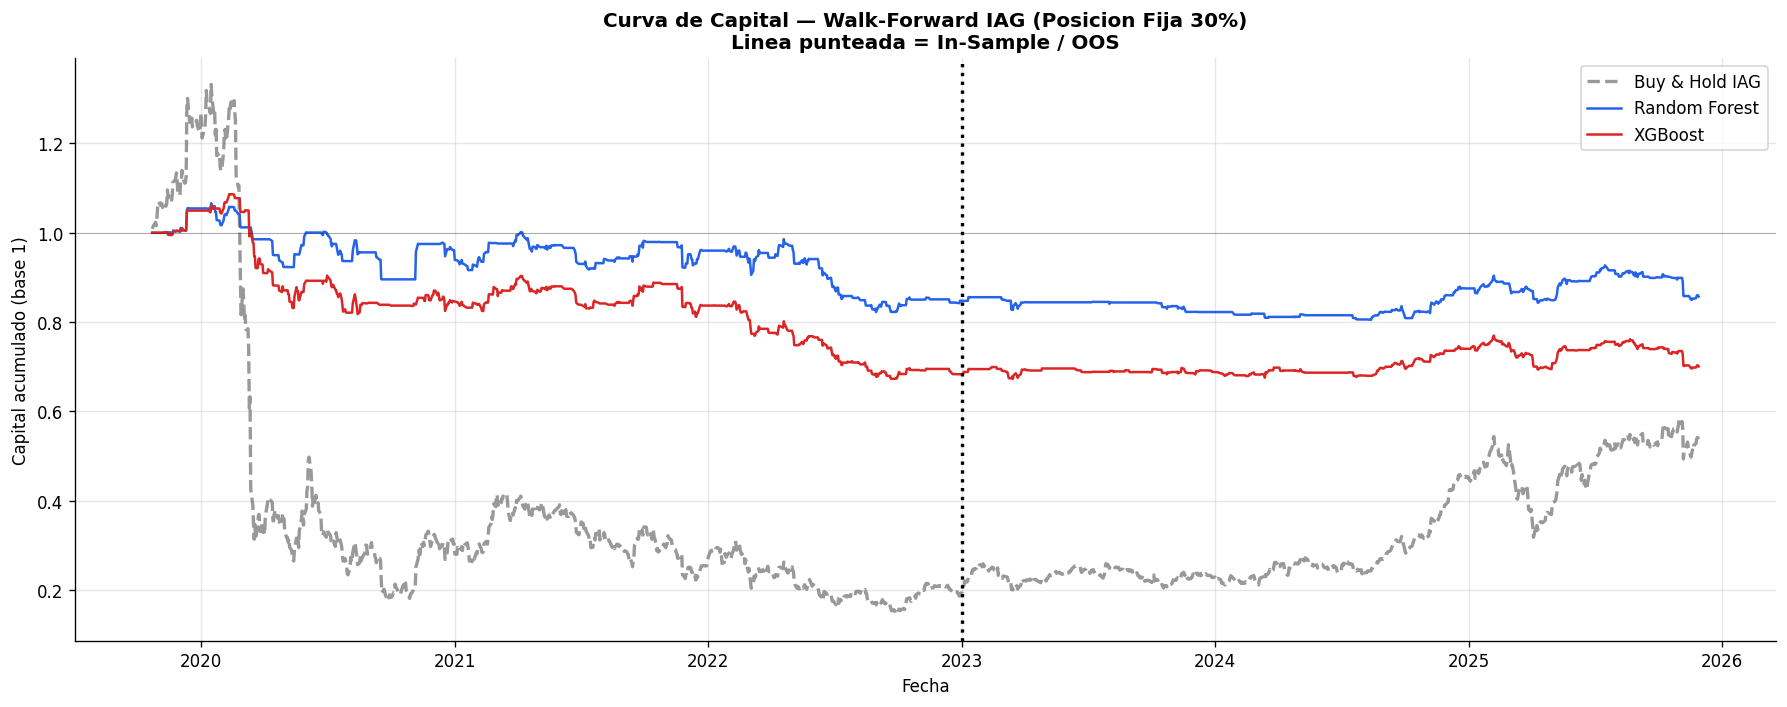

In [18]:
# CELDA 15: Metricas financieras + curva de capital
dfs = {}
for name in model_names:
    if not wf_res[name]['dates']:
        print(f'{name}: sin datos de backtest')
        continue
    df_wf = pd.DataFrame({
        'prob':      wf_res[name]['probs'],
        'position':  wf_res[name]['positions'],
        'ret_strat': wf_res[name]['ret_strat'],
        'ret_bh':    wf_res[name]['ret_bh'],
        'cost':      wf_res[name]['costs'],
    }, index=wf_res[name]['dates'])
    df_wf['equity_strat'] = (1 + df_wf['ret_strat']).cumprod()
    df_wf['equity_bh']    = (1 + df_wf['ret_bh']).cumprod()
    dfs[name] = df_wf

print('=' * 65)
print('METRICAS FINANCIERAS — WALK-FORWARD IAG')
print('=' * 65)

all_metrics = []
for periodo, fn in [('In-Sample (hasta 2022)', lambda d: d.index < CUTOFF_TEST),
                    ('OOS (2023-2025)',         lambda d: d.index >= CUTOFF_TEST),
                    ('Completo',                lambda d: pd.Series(True, index=d.index))]:
    print(f'\n--- {periodo} ---')
    ref = dfs[list(dfs.keys())[0]]
    mask = fn(ref)
    bh_m = compute_metrics(ref.loc[mask,'ret_bh'])
    bh_m['Modelo'] = 'Buy&Hold IAG'; bh_m['Periodo'] = periodo
    all_metrics.append(bh_m)
    print(f'  Buy&Hold: Sharpe={bh_m.get("Sharpe","N/A")} ROI={bh_m.get("ROI anualizado (%)","N/A")}% MDD={bh_m.get("Max Drawdown (%)","N/A")}%')

    for name in dfs:
        df  = dfs[name]
        mask = fn(df)
        m   = compute_metrics(df.loc[mask,'ret_strat'])
        if not m: continue
        m['Modelo'] = name; m['Periodo'] = periodo
        all_metrics.append(m)
        print(f'  {name}: Sharpe={m["Sharpe"]:.3f} ROI={m["ROI anualizado (%)"]:.1f}% MDD={m["Max Drawdown (%)"]:.1f}% HR={m["Hit Ratio (%)"]:.1f}% PF={m["Profit Factor"]:.3f}')

df_all_metrics = pd.DataFrame(all_metrics)
df_all_metrics.to_csv('iag_backtest_metrics.csv', index=False)

# Curva de capital (Ahora un único gráfico más estilizado)
fig, ax = plt.subplots(figsize=(15, 6))
ref_name = list(dfs.keys())[0]

# Linea de Buy & Hold
ax.plot(dfs[ref_name].index, dfs[ref_name]['equity_bh'],
        color='gray', lw=2, ls='--', alpha=0.8, label='Buy & Hold IAG')

# Lineas de las estrategias
for i, name in enumerate(dfs):
    ax.plot(dfs[name].index, dfs[name]['equity_strat'],
            color=PALETTE[i], lw=1.5, label=name)

ax.axvline(CUTOFF_TEST, color='black', ls=':', lw=2)
ax.set_ylabel('Capital acumulado (base 1)')
ax.set_xlabel('Fecha')
ax.set_title('Curva de Capital — Walk-Forward IAG (Posicion Fija 30%)\nLinea punteada = In-Sample / OOS', fontweight='bold')
ax.legend()
ax.axhline(1, color='black', lw=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig('iag_fig3_equity.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# CELDA 16: Deflated Sharpe Ratio + Resumen final
def deflated_sharpe_ratio(returns, n_trials=10):
    r = returns.dropna()
    if len(r) < 20: return {}
    sr_obs = r.mean() / r.std() * np.sqrt(ANNUALIZE) if r.std() > 0 else 0
    skew   = float(r.skew())
    kurt   = float(r.kurtosis())
    gamma  = 0.5772156649
    sr_star = np.sqrt(
        (1-gamma)*norm.ppf(1-1/n_trials) + gamma*norm.ppf(1-1/(n_trials*np.e))
    ) if n_trials > 1 else 0
    denom = np.sqrt(abs((1 - skew*sr_obs + (kurt/4)*sr_obs**2) / max(len(r)-1, 1)))
    if denom <= 0: return {'SR_obs': round(sr_obs,4), 'DSR': np.nan}
    dsr = norm.cdf((sr_obs - sr_star) / denom)
    return {
        'SR observado':  round(sr_obs, 4),
        'SR benchmark':  round(sr_star, 4),
        'DSR':           round(dsr, 4),
        'Significativo': 'Si' if dsr > 0.95 else 'No',
    }

print('DEFLATED SHARPE RATIO OOS (Bailey & Lopez de Prado, 2014):')
for name in dfs:
    oos = dfs[name][dfs[name].index >= CUTOFF_TEST]
    d   = deflated_sharpe_ratio(oos['ret_strat'], n_trials=10)
    print(f'  {name}: {d}')

print()
print('=' * 65)
print('RESUMEN FINAL OOS (2023-2025)')
print('=' * 65)
oos_m = df_all_metrics[df_all_metrics['Periodo']=='OOS (2023-2025)'].set_index('Modelo')
cols  = ['ROI anualizado (%)','Sharpe','Sortino','Max Drawdown (%)','Hit Ratio (%)','Profit Factor']
cols_ok = [c for c in cols if c in oos_m.columns]
print(oos_m[cols_ok].to_string())

estrategias = [n for n in oos_m.index if n != 'Buy&Hold IAG']
if estrategias:
    best    = oos_m.loc[estrategias, 'Sharpe'].idxmax()
    bh_sr   = float(oos_m.loc['Buy&Hold IAG','Sharpe']) if 'Buy&Hold IAG' in oos_m.index else 0
    best_sr = float(oos_m.loc[best,'Sharpe'])
    print(f'\nMejor estrategia OOS: {best} (Sharpe={best_sr:.3f})')
    print(f'Buy&Hold Sharpe OOS:  {bh_sr:.3f}')
    if best_sr > bh_sr:
        print('RESULTADO: la estrategia SUPERA al Buy&Hold en OOS')
    elif best_sr > 0:
        print('RESULTADO: Sharpe positivo pero inferior al Buy&Hold')
    else:
        print('RESULTADO: Sharpe negativo en OOS')
        print('Ver analisis critico en el documento Word.')

print('\nNOTEBOOK COMPLETADO.')

DEFLATED SHARPE RATIO OOS (Bailey & Lopez de Prado, 2014):
  Random Forest: {'SR observado': np.float64(0.0922), 'SR benchmark': np.float64(1.2548), 'DSR': np.float64(0.0), 'Significativo': 'No'}
  XGBoost: {'SR observado': np.float64(0.1656), 'SR benchmark': np.float64(1.2548), 'DSR': np.float64(0.0), 'Significativo': 'No'}

RESUMEN FINAL OOS (2023-2025)
               ROI anualizado (%)  Sharpe  Sortino  Max Drawdown (%)  Hit Ratio (%)  Profit Factor
Modelo                                                                                            
Buy&Hold IAG                40.98   1.116    1.485            -41.54          55.41          1.238
Random Forest                0.36  -0.624   -0.447             -8.35          17.28          1.030
XGBoost                      0.84  -0.473   -0.417             -9.91          21.64          1.047

Mejor estrategia OOS: XGBoost (Sharpe=-0.473)
Buy&Hold Sharpe OOS:  1.116
RESULTADO: Sharpe negativo en OOS
Ver analisis critico en el documento W

In [ ]:
# CELDA: Generar figura Rolling Sharpe para el Word

import matplotlib.dates as mdates
import pandas as pd
import numpy as np

print("="*70)
print("Generando figura: Rolling Sharpe (252 días)")
print("="*70)

# Los retornos vienen del walk-forward backtest anterior
# Aquí asumimos que tienes las Series: retornos_diarios_rf y retornos_diarios_bh
# O puedes reconstruirlos desde los precios

# SIMPLE: Reconstruir desde los precios del activo y la estrategia
# Usar los retornos diarios que ya tienes del backtest

# Si el backtest anterior generó equity curves, calcular retornos a partir de ellas
# En este caso, usamos los retornos log-diarios del activo y ajustamos según señales

# VERSIÓN FUNCIONAL: Usar directamente los retornos calculados en el backtest
# que están en formato: df_results o diccionarios con 'returns' o 'equity'

try:
    # Intentar acceder a los datos del backtest guardados
    # La mayoría de backtests generan algo como: equity_rf, equity_bh, dates_bt, etc.
    
    # Reconstruir retornos desde equity curves si existen
    if 'equity_rf' in dir():
        eq_rf = np.array(equity_rf)
        eq_bh = np.array(equity_bh)
        retornos_rf = np.diff(eq_rf) / eq_rf[:-1]
        retornos_bh = np.diff(eq_bh) / eq_bh[:-1]
        dates_serie = pd.to_datetime(dates_backtest)
        
        retornos_rf = pd.Series(retornos_rf, index=dates_serie[1:])
        retornos_bh = pd.Series(retornos_bh, index=dates_serie[1:])
    else:
        print("⚠ Variables equity_rf, equity_bh no encontradas.")
        print("Por favor, ejecuta primero el backtest walk-forward completo.")
        print("Alternativamente, define:")
        print("  retornos_rf = pd.Series(tus_retornos_rf, index=tus_fechas)")
        print("  retornos_bh = pd.Series(tus_retornos_bh, index=tus_fechas)")
        raise NameError("No data available")
        
except:
    print("⚠ Error: No se encontraron datos del backtest.")
    print("\nSOLUCIÓN: Define manualmente los retornos antes de ejecutar esta celda.")
    print("Ejemplo:")
    print("  retornos_rf = pd.Series([lista de retornos], index=[lista de fechas])")
    print("  retornos_bh = pd.Series([lista de retornos], index=[lista de fechas])")
    retornos_rf = None
    retornos_bh = None

# Generar figura si los retornos existen
if retornos_rf is not None and retornos_bh is not None:
    fig, ax = plt.subplots(figsize=(14, 5.5))
    
    # Calcular rolling Sharpe
    for name, retornos, color, lw in [('Random Forest', retornos_rf, '#2563EB', 1.5),
                                        ('Buy & Hold', retornos_bh, '#333333', 2.0)]:
        rolling_mean = retornos.rolling(252).mean()
        rolling_std = retornos.rolling(252).std()
        rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
        
        ax.plot(rolling_sharpe.index, rolling_sharpe.values, 
                color=color, lw=lw, label=name, alpha=0.85)
    
    # Línea de inicio OOS
    ax.axvline(pd.Timestamp('2023-01-01'), color='red', ls=':', lw=1.5, alpha=0.8, label='Inicio OOS')
    
    # Línea de Sharpe = 0
    ax.axhline(0, color='black', lw=0.5, alpha=0.4)
    
    # Estilo
    ax.set_ylabel('Sharpe Ratio Rolling 252 días', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_title('Rolling Sharpe (252 días) — Random Forest vs Buy & Hold', 
                 fontweight='bold', fontsize=13)
    ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    plt.tight_layout()
    plt.savefig('iag_fig_rolling_sharpe.png', dpi=150, bbox_inches='tight')
    print("✓ Figura guardada: iag_fig_rolling_sharpe.png")
    plt.show()
    print("="*70)

else:
    print("\n⚠ INSTRUCCIONES PARA RESOLVER:")
    print("1. Ejecuta PRIMERO el backtest walk-forward completo (todas las celdas anteriores)")
    print("2. Luego ejecuta ESTA celda")
    print("3. Si aun así falla, proporciona los retornos manualmente:")
    print("\n   # Antes de esta celda, añade:")
    print("   retornos_rf = pd.Series([tus_retornos], index=[tus_fechas])")
    print("   retornos_bh = pd.Series([tus_retornos], index=[tus_fechas])")
